In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.formula.api as smf

# Load the DataFrame, assuming 'combined_rentals_weather_wind_2024.csv' is available
df = pd.read_csv('combined_rentals_weather_wind_2024.csv')

columns_to_correlate = ['rental',	'temp',	'rel_humidity',	'wb_temp', 'precip_in', 'wind_speed']
correlation_matrix = df[columns_to_correlate].corr()
display(correlation_matrix)

with open('cor_matrix.tex', 'w') as f:
    f.write(correlation_matrix.to_latex(float_format="{:.4f}".format))

,rental,temp,rel_humidity,wb_temp,precip_in,wind_speed
rental,1.000000,0.435417,-0.179676,0.299679,-0.098294,0.018448
temp,0.435417,1.000000,-0.009251,0.881305,-0.031780,-0.079446
rel_humidity,-0.179676,-0.009251,1.000000,0.455338,0.227697,-0.193450
wb_temp,0.299679,0.881305,0.455338,1.000000,0.063362,-0.162062
precip_in,-0.098294,-0.031780,0.227697,0.063362,1.000000,0.125269
wind_speed,0.018448,-0.079446,-0.193450,-0.162062,0.125269,1.000000


<ipython-input-32-fef37ef3fe84>:15: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(correlation_matrix.to_latex(float_format="{:.4f}".format))


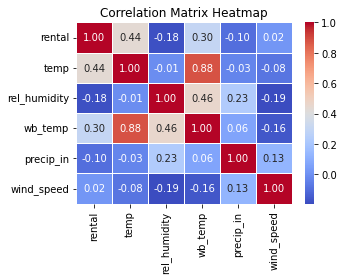

In [33]:
plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('correlation_matrix_heatmap.eps') # Save the plot
plt.show()

In [34]:
ybar = df['rental'].mean()
print(f"Average number of rentals per hour: {ybar:.2f}")
residuals = df['rental'] - ybar
SST = (residuals ** 2).sum()
print(f"Total sum of squares (SST): {SST:.2f}")

Average number of rentals per hour: 540.96
Total sum of squares (SST): 2214094429.73


In [35]:
covariance = df['rental'].cov(df['temp'])
print(f"Covariance between rentals and temp: {covariance:.2f}")

Covariance between rentals and temp: 3630.28


In [36]:
correlation = df['rental'].corr(df['temp'])
print(f"Correlation between rentals and temp: {correlation:.4f}")

Correlation between rentals and temp: 0.4354


# Simple Linear Regression: Rentals vs. Temperature

                            OLS Regression Results                            
Dep. Variable:                 rental   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     2054.
Date:                Mon, 07 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:05:13   Log-Likelihood:                -66166.
No. Observations:                8784   AIC:                         1.323e+05
Df Residuals:                    8782   BIC:                         1.323e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -162.9036     16.261    -10.018      0.0

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


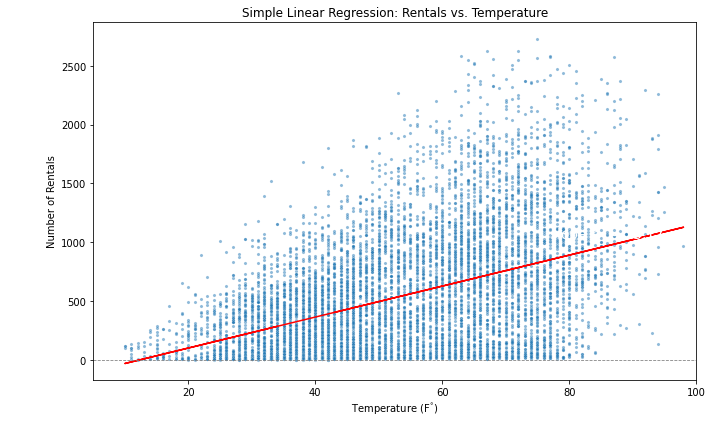

In [37]:
# Perform linear regression using statsmodels OLS
model = smf.ols('rental ~ temp', data=df).fit()

print(model.summary())

# Extract coefficients
slope = model.params['temp']
intercept = model.params['Intercept']
r_value_squared = model.rsquared
p_value = model.pvalues['temp']
std_err = model.bse['temp'] # Standard error of the slope
ssr = model.ssr

print(f"\nSlope: {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {r_value_squared:.2f}")
print(f"P-value: {p_value:.3f}")
print(f"Standard Error (Slope): {std_err:.2f}")
print(f"Sum of Squares of Residuals (SSR): {ssr:.2f}")

# Create the regression line values
df['regression_line'] = slope * df['temp'] + intercept

# Plotting
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp', y='rental', data=df, alpha=0.5, s=10) # Reduced marker size to 20
plt.plot(df['temp'], df['regression_line'], color='red', linestyle='-', label=f'Regression Line (y = {slope:.2f}x + {intercept:.2f})')

plt.xlim(5,100)
#plt.ylim(-150,1350)
# Add label for intercept b0
plt.text(plt.gca().get_xlim()[0], intercept, f'$b_0 = {intercept:.2f}$',
         verticalalignment='center', horizontalalignment='right', color='white', fontsize=12)
# Add label for slope b1
plt.text(plt.gca().get_xlim()[1] * 0.95, plt.gca().get_ylim()[1] * 0.4,
         f'slope $b_1 = {slope:.2f}$', verticalalignment='top', horizontalalignment='right', color='white', fontsize=14)

plt.title('Simple Linear Regression: Rentals vs. Temperature')
plt.xlabel('Temperature (F$^°$)')
plt.ylabel('Number of Rentals')
plt.grid(False)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
# plt.legend()
plt.tight_layout()
plt.savefig('rentals_vs_temp_linear_regression_statsmodels.eps') # Save the plot
plt.show()

In [38]:
predicted_rental = model.predict(pd.DataFrame({'temp': [75]}))
print(f"Predicted rentals at {75}°F: {predicted_rental.iloc[0]:.2f}")

Predicted rentals at 75°F: 824.48


In [39]:
print(f"SSR for model: {model.ssr:.2f}")

SSR for model: 1794328310.55


In [40]:
model1 = smf.ols('rental ~ temp + rel_humidity', data=df).fit()
print(model1.summary())

model2 = smf.ols('rental ~ temp + rel_humidity + precip_in + wind_speed', data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 rental   R-squared:                       0.220
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     1242.
Date:                Mon, 07 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:05:14   Log-Likelihood:                -65995.
No. Observations:                8784   AIC:                         1.320e+05
Df Residuals:                    8781   BIC:                         1.320e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      148.6319     23.100      6.434   

In [41]:
model2 = smf.ols('rental ~ temp + wb_temp + rel_humidity', data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                 rental   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     831.6
Date:                Mon, 07 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:05:14   Log-Likelihood:                -65991.
No. Observations:                8784   AIC:                         1.320e+05
Df Residuals:                    8780   BIC:                         1.320e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     -179.6712    110.221     -1.630   

In [42]:
model3 = smf.ols('rental ~ temp + rel_humidity + hour', data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                 rental   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.324
Method:                 Least Squares   F-statistic:                     1401.
Date:                Mon, 07 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:05:14   Log-Likelihood:                -65371.
No. Observations:                8784   AIC:                         1.307e+05
Df Residuals:                    8780   BIC:                         1.308e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     -187.0446     23.386     -7.998   

In [43]:
model4 = smf.ols('rental ~ temp + rel_humidity + C(hour)', data=df).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                 rental   R-squared:                       0.709
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     854.5
Date:                Mon, 07 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:05:14   Log-Likelihood:                -61664.
No. Observations:                8784   AIC:                         1.234e+05
Df Residuals:                    8758   BIC:                         1.236e+05
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      -316.5762     19.831    -15.963

In [44]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
from scipy import stats

def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    summary_table = model.summary2().tables[1]
    summary_table['Signif'] = summary_table['P>|t|'].apply(significance_stars)

    # Round all numeric columns to 4 decimal places
    rounded_table = summary_table.round(4)

    # Get the string representation of the table with header
    table_string = rounded_table.to_string(header=True)

    # Split the string into lines
    lines = table_string.split('\n')

    # Print the header line
    print("=" * len(lines[0]))
    print(lines[0])
    # Print the separator line
    print("-" * len(lines[0]))
    # Print the rest of the table data
    print('\n'.join(lines[1:]))
    print("=" * len(lines[0]))
    print(f"R-squared: {model.rsquared:.4f}  ***:p<0.001  **:p<0.01  *:p<0.05  .:p<0.1")

In [45]:
modelstar = smf.ols('rental ~ temp + rel_humidity + precip_in + wind_speed', data=df).fit()
print_summary_with_stars(modelstar)

                  Coef.  Std.Err.        t   P>|t|     [0.025    0.975] Signif
------------------------------------------------------------------------------
Intercept       90.9664   27.7799   3.2745  0.0011    36.5114  145.4214     **
temp            13.1402    0.2854  46.0376  0.0000    12.5807   13.6997    ***
rel_humidity    -4.0696    0.2554 -15.9368  0.0000    -4.5702   -3.5691    ***
precip_in    -1125.3808  212.1237  -5.3053  0.0000 -1541.1929 -709.5687    ***
wind_speed       3.2663    1.1047   2.9569  0.0031     1.1009    5.4317     **
R-squared: 0.2233  ***:p<0.001  **:p<0.01  *:p<0.05  .:p<0.1
